In [ ]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, f1_score, roc_auc_score
)
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import kagglehub
path1 = kagglehub.dataset_download('glendell03/water-hyacinth')
path2 = kagglehub.dataset_download('kalyanitewari/waterhyacinth-a-dataset-of-water-hyacinth-species')
print('Dataset 1:', path1)
print('Dataset 2:', path2)


Using Colab cache for faster access to the 'water-hyacinth' dataset.
Using Colab cache for faster access to the 'waterhyacinth-a-dataset-of-water-hyacinth-species' dataset.
Dataset 1: /kaggle/input/water-hyacinth
Dataset 2: /kaggle/input/waterhyacinth-a-dataset-of-water-hyacinth-species


In [ ]:
import os, shutil
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# ------------------------------
# 1. Copy images into folders
# ------------------------------
root_dir               = '/content/dataset'
water_hyacinth_dir     = os.path.join(root_dir, 'water_hyacinth')
not_water_hyacinth_dir = os.path.join(root_dir, 'not_water_hyacinth')
os.makedirs(water_hyacinth_dir,     exist_ok=True)
os.makedirs(not_water_hyacinth_dir, exist_ok=True)

# DS1 — all positive
d1_src = os.path.join(path1, 'imagesv2')
for fname in os.listdir(d1_src):
    if fname.lower().endswith('.jpg'):
        shutil.copy(os.path.join(d1_src, fname),
                    os.path.join(water_hyacinth_dir, f'd1_{fname}'))

# DS2 — binary mapping
d2_main   = os.path.join(path2,
    'WaterHyacinth A Comprehensive Image Dataset of Various '
    'Water Hyacinth Species From Different Regions of Bangladesh')
d2_images = os.path.join(d2_main, 'Original', 'Original Images')
for class_name in os.listdir(d2_images):
    class_path = os.path.join(d2_images, class_name)
    if not os.path.isdir(class_path): continue
    target_folder = (water_hyacinth_dir if 'Water Hyacinth' in class_name
                     else not_water_hyacinth_dir)
    for fname in os.listdir(class_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            shutil.copy(os.path.join(class_path, fname),
                        os.path.join(target_folder, f'd2_{class_name[:5]}_{fname}'))

print(f"water_hyacinth:     {len(os.listdir(water_hyacinth_dir))}")
print(f"not_water_hyacinth: {len(os.listdir(not_water_hyacinth_dir))}")

# ------------------------------
# 2. Collect all file paths and labels
# ------------------------------
SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

all_files = []
all_labels = []

# Class 0: not_water_hyacinth
for fname in os.listdir(not_water_hyacinth_dir):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        all_files.append(os.path.join(not_water_hyacinth_dir, fname))
        all_labels.append(0)

# Class 1: water_hyacinth
for fname in os.listdir(water_hyacinth_dir):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        all_files.append(os.path.join(water_hyacinth_dir, fname))
        all_labels.append(1)

all_files = np.array(all_files)
all_labels = np.array(all_labels)

print(f"Total images: {len(all_files)} (class0: {np.sum(all_labels==0)}, class1: {np.sum(all_labels==1)})")

# ------------------------------
# 3. Extract exactly 200 per class for test set
# ------------------------------
np.random.seed(SEED)
idx_class0 = np.where(all_labels == 0)[0]
idx_class1 = np.where(all_labels == 1)[0]

if len(idx_class0) < 200 or len(idx_class1) < 200:
    raise ValueError(f"Not enough images per class: class0={len(idx_class0)}, class1={len(idx_class1)}. Need at least 200 each.")

test_idx0 = np.random.choice(idx_class0, 200, replace=False)
test_idx1 = np.random.choice(idx_class1, 200, replace=False)
test_idx = np.concatenate([test_idx0, test_idx1])

# Remaining indices for train+val
trainval_idx = np.setdiff1d(np.arange(len(all_files)), test_idx)
trainval_files = all_files[trainval_idx]
trainval_labels = all_labels[trainval_idx]

# ------------------------------
# 4. Split trainval into train (70% of trainval) and val (30% of trainval), stratified
# ------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    trainval_files, trainval_labels,
    test_size=0.3, stratify=trainval_labels, random_state=SEED
)

print(f"Train size: {len(X_train)} (class0: {np.sum(np.array(y_train)==0)}, class1: {np.sum(np.array(y_train)==1)})")
print(f"Val size:   {len(X_val)}   (class0: {np.sum(np.array(y_val)==0)}, class1: {np.sum(np.array(y_val)==1)})")
print(f"Test size:  {len(test_idx)} (class0: 200, class1: 200)")

# ------------------------------
# 5. Build tf.data Datasets with FIXED decode+resize
# ------------------------------
def build_dataset(files, labels, batch_size=BATCH_SIZE, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))

    def load_and_resize(path, label):
        img_bytes = tf.io.read_file(path)
        # Decode image (JPEG/PNG) to uint8, force 3 channels
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        # Set static shape [height, width, 3] to make resize happy
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, IMAGE_SIZE)
        img = tf.cast(img, tf.float32)   # EfficientNetV2 expects float [0,255]? Original used uint8, but float is fine.
        return img, label

    ds = ds.map(load_and_resize, num_parallel_calls=AUTOTUNE)

    if augment:
        ds = ds.map(lambda img, label: (tf.image.random_flip_left_right(img), label),
                    num_parallel_calls=AUTOTUNE)
        # You can add more augmentation (brightness, contrast) here if desired

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(X_train, y_train, augment=True)
val_ds   = build_dataset(X_val,   y_val,   augment=False)
test_ds  = build_dataset(all_files[test_idx], all_labels[test_idx], augment=False)

# Verify test class distribution
# Verify test class distribution (robust way)
test_labels_list = []
for _, y in test_ds.unbatch():
    test_labels_list.append(int(y.numpy()))
test_labels_arr = np.array(test_labels_list)
print(f"Test class distribution: {np.bincount(test_labels_arr)}")  # should be [200, 200]

water_hyacinth:     1054
not_water_hyacinth: 1320
Total images: 2374 (class0: 1320, class1: 1054)
Train size: 1381 (class0: 784, class1: 597)
Val size:   593   (class0: 336, class1: 257)
Test size:  400 (class0: 200, class1: 200)
Test class distribution: [200 200]


In [ ]:
SEED       = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    root_dir, validation_split=0.3, subset='training',
    seed=SEED, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

raw_temp_val_ds = tf.keras.utils.image_dataset_from_directory(
    root_dir, validation_split=0.3, subset='validation',
    seed=SEED, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

class_names   = raw_train_ds.class_names
temp_batches  = tf.data.experimental.cardinality(raw_temp_val_ds)
val_batches   = temp_batches // 2

val_ds  = raw_temp_val_ds.take(val_batches)
test_ds = raw_temp_val_ds.skip(val_batches)

print(f"Classes: {class_names}")
print(f"Train batches: {tf.data.experimental.cardinality(raw_train_ds).numpy()}")
print(f"Val   batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test  batches: {tf.data.experimental.cardinality(test_ds).numpy()}")


Found 2374 files belonging to 2 classes.
Using 1662 files for training.
Found 2374 files belonging to 2 classes.
Using 712 files for validation.
Classes: ['not_water_hyacinth', 'water_hyacinth']
Train batches: 52
Val   batches: 11
Test  batches: 12


In [ ]:
y_train = np.concatenate([y.numpy().flatten() for _, y in raw_train_ds])
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weights)


Class weights: {0: 0.8945102260495156, 1: 1.1336971350613916}


In [ ]:
def augment_plant(image, label):
    """Spatial + moderate photometric augmentation.
    Operates on a single 3-D image tensor [H, W, C] — called after unbatch().
    Keeps hue changes tiny so plant-colour cues are preserved."""
    image = tf.cast(image, tf.float32)

    # Spatial
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image,
                           tf.random.uniform([], 0, 4, dtype=tf.int32))

    # Photometric
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
    image = tf.image.random_saturation(image, lower=0.85, upper=1.15)
    image = tf.image.random_hue(image, max_delta=0.04)   # very conservative

    # Scale jitter: random crop then resize back
    # shape is [H, W, C] — 3 elements — because we unbatch() before mapping
    shape  = tf.shape(image)          # [H, W, 3]
    frac   = tf.random.uniform([], 0.80, 1.00)
    crop_h = tf.cast(tf.cast(shape[0], tf.float32) * frac, tf.int32)
    crop_w = tf.cast(tf.cast(shape[1], tf.float32) * frac, tf.int32)
    image  = tf.image.random_crop(image, tf.stack([crop_h, crop_w, shape[2]]))
    image  = tf.image.resize(image, IMAGE_SIZE)

    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, label

# CORRECT cache order:
# 1. unbatch first  → individual [224,224,3] images
# 2. cache the unbatched images (no repeated disk reads)
# 3. shuffle → augment → re-batch
# Putting cache() BEFORE unbatch() confuses TF's step counter → 'ran out of data' warning
# AFTER — paste this instead:
def mixup_batch(images, labels, alpha=0.2):
    batch_size = tf.shape(images)[0]
    lam = tf.random.uniform([], 0.0, alpha)
    idx = tf.random.shuffle(tf.range(batch_size))
    mixed_images = lam * images + (1 - lam) * tf.gather(images, idx)
    mixed_labels = lam * labels + (1 - lam) * tf.gather(labels, idx)
    return mixed_images, mixed_labels

train_ds = (raw_train_ds
            .unbatch()
            .cache()
            .shuffle(2000)
            .map(augment_plant, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .map(mixup_batch, num_parallel_calls=AUTOTUNE)   # ← Mixup added
            .prefetch(AUTOTUNE))

STEPS_PER_EPOCH = tf.data.experimental.cardinality(train_ds).numpy()
if STEPS_PER_EPOCH <= 0:
    n_train = len(y_train)
    STEPS_PER_EPOCH = n_train // BATCH_SIZE
print(f"Steps per epoch: {STEPS_PER_EPOCH}")

val_ds  = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)



Steps per epoch: 51


In [ ]:
# REPLACE FocalLoss class (lines 146-167) entirely with:
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.65, smoothing=0.05, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma; self.alpha = alpha; self.smoothing = smoothing

    def call(self, y_true, y_pred):
        y_true  = y_true * (1 - self.smoothing) + self.smoothing * 0.5
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        bce     = -y_true*tf.math.log(y_pred) - (1-y_true)*tf.math.log(1-y_pred)
        pt      = y_true*y_pred + (1-y_true)*(1-y_pred)
        fw      = (1 - pt) ** self.gamma
        alpha_t = y_true*self.alpha + (1-y_true)*(1-self.alpha)
        return tf.reduce_mean(alpha_t * fw * bce)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma':self.gamma,'alpha':self.alpha,'smoothing':self.smoothing})
        return cfg

# Then in both model.compile() calls change to:
loss=FocalLossSmoothed(gamma=2.0, alpha=0.65, smoothing=0.05),



In [ ]:
base_model = applications.EfficientNetV2S(          # V2S > B0 > MobileNetV2
    input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs  = layers.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)        # V2 has built-in preprocessing
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)            # ADD
x       = layers.Dropout(0.4)(x)                   # 0.3 → 0.4
outputs = layers.Dense(1, activation='sigmoid')(x)


model   = models.Model(inputs, outputs)

model.summary()

METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc'),
]

model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss=FocalLoss(gamma=2.0, alpha=0.75),
    metrics=METRICS)



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,337,761 (77.58 MB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 20,333,920 (77.57 MB)

In [ ]:
PHASE1_EPOCHS = 30

cb_phase1 = [
    callbacks.EarlyStopping(
        monitor='val_auc', patience=5,
        restore_best_weights=True, mode='max'),
    callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5,
        patience=3, mode='max', min_lr=1e-7),
    callbacks.ModelCheckpoint(
        'best_phase1.h5', monitor='val_auc',
        save_best_only=True, mode='max'),
]

print("=== Phase 1: Feature Extraction ===")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=cb_phase1,
    class_weight=class_weights)


=== Phase 1: Feature Extraction ===
Epoch 1/30
     52/Unknown 133s 750ms/step - accuracy: 0.2324 - auc: 0.4920 - loss: 0.2337 - precision: 0.6636 - recall: 0.4972

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


52/52 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.2599 - auc: 0.5164 - loss: 0.2183 - precision: 0.7031 - recall: 0.5243 - val_accuracy: 0.5710 - val_auc: 0.6135 - val_loss: 0.0789 - val_precision: 0.5068 - val_recall: 0.7273 - learning_rate: 1.0000e-04
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.2933 - auc: 0.5835 - loss: 0.1845 - precision: 0.7179 - recall: 0.5731

52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.3069 - auc: 0.5900 - loss: 0.1738 - precision: 0.7195 - recall: 0.5805 - val_accuracy: 0.6193 - val_auc: 0.7160 - val_loss: 0.0695 - val_precision: 0.5424 - val_recall: 0.8312 - learning_rate: 1.0000e-04
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.3167 - auc: 0.5902 - loss: 0.1587 - precision: 0.7296 - recall: 0.6113

52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.3117 - auc: 0.6100 - loss: 0.1530 - precision: 0.7371 - recall: 0.6188 - val_accuracy: 0.6619 - val_auc: 0.7955 - val_loss: 0.0616 - val_precision: 0.5720 - val_recall: 0.9026 - learning_rate: 1.0000e-04
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.2960 - auc: 0.6324 - loss: 0.1351 - precision: 0.7773 - recall: 0.6489

...

52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 155ms/step - accuracy: 0.4398 - auc: 0.7720 - loss: 0.0507 - precision: 0.8547 - recall: 0.6622 - val_accuracy: 0.8977 - val_auc: 0.9756 - val_loss: 0.0238 - val_precision: 0.8352 - val_recall: 0.9545 - learning_rate: 1.0000e-04
Epoch 27/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4136 - auc: 0.7921 - loss: 0.0479 - precision: 0.8716 - recall: 0.6620

52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.4182 - auc: 0.7861 - loss: 0.0513 - precision: 0.8643 - recall: 0.6684 - val_accuracy: 0.9062 - val_auc: 0.9771 - val_loss: 0.0231 - val_precision: 0.8457 - val_recall: 0.9610 - learning_rate: 1.0000e-04
Epoch 28/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.4228 - auc: 0.7824 - loss: 0.0502 - precision: 0.8868 - recall: 0.6617

52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - accuracy: 0.4140 - auc: 0.7725 - loss: 0.0518 - precision: 0.8671 - recall: 0.6545 - val_accuracy: 0.9062 - val_auc: 0.9781 - val_loss: 0.0226 - val_precision: 0.8457 - val_recall: 0.9610 - learning_rate: 1.0000e-04
Epoch 29/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.4478 - auc: 0.7735 - loss: 0.0605 - precision: 0.8733 - recall: 0.6806

52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.4404 - auc: 0.7682 - loss: 0.0568 - precision: 0.8677 - recall: 0.6696 - val_accuracy: 0.9062 - val_auc: 0.9791 - val_loss: 0.0222 - val_precision: 0.8497 - val_recall: 0.9545 - learning_rate: 1.0000e-04
Epoch 30/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.4242 - auc: 0.7977 - loss: 0.0411 - precision: 0.8846 - recall: 0.6895

52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.4350 - auc: 0.7903 - loss: 0.0438 - precision: 0.8691 - recall: 0.6693 - val_accuracy: 0.9119 - val_auc: 0.9798 - val_loss: 0.0217 - val_precision: 0.8555 - val_recall: 0.9610 - learning_rate: 1.0000e-04


In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after unfreezing: {trainable_count}")

# Cosine decay schedule for fine-tuning
PHASE2_EPOCHS  = 40
total_steps    = PHASE2_EPOCHS * STEPS_PER_EPOCH   # STEPS_PER_EPOCH set in CELL 6
lr_schedule    = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=total_steps,
    alpha=1e-7)

model.compile(
    optimizer=optimizers.Adam(lr_schedule),
    loss=FocalLoss(gamma=2.0, alpha=0.65),
    metrics=METRICS)

cb_phase2 = [
    callbacks.EarlyStopping(
        monitor='val_auc', patience=7,
        restore_best_weights=True, mode='max'),
    callbacks.ModelCheckpoint(
        'best_phase2.h5', monitor='val_auc',
        save_best_only=True, mode='max'),
]

print("=== Phase 2: Fine-Tuning (top 30 layers) ===")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=cb_phase2,
    class_weight=class_weights)



Trainable layers after unfreezing: 6
=== Phase 2: Fine-Tuning (top 30 layers) ===
Epoch 1/40
     52/Unknown 99s 732ms/step - accuracy: 0.4076 - auc: 0.8299 - loss: 0.0661 - precision: 0.8423 - recall: 0.7374

52/52 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.4140 - auc: 0.7965 - loss: 0.0606 - precision: 0.8476 - recall: 0.6905 - val_accuracy: 0.8949 - val_auc: 0.9716 - val_loss: 0.0297 - val_precision: 0.8382 - val_recall: 0.9416
Epoch 2/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4124 - auc: 0.7722 - loss: 0.0637 - precision: 0.8893 - recall: 0.6455

52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - accuracy: 0.4230 - auc: 0.7744 - loss: 0.0583 - precision: 0.8740 - recall: 0.6503 - val_accuracy: 0.8892 - val_auc: 0.9766 - val_loss: 0.0274 - val_precision: 0.8249 - val_recall: 0.9481
Epoch 3/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.4141 - auc: 0.7640 - loss: 0.0662 - precision: 0.8782 - recall: 0.6337

52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step - accuracy: 0.4284 - auc: 0.7840 - loss: 0.0575 - precision: 0.8628 - recall: 0.6549 - val_accuracy: 0.9148 - val_auc: 0.9800 - val_loss: 0.0240 - val_precision: 0.8827 - val_recall: 0.9286
Epoch 4/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.4352 - auc: 0.7857 - loss: 0.0575 - precision: 0.8909 - recall: 0.6537

52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 175ms/step - accuracy: 0.4699 - auc: 0.8023 - loss: 0.0518 - precision: 0.9051 - recall: 0.6571 - val_accuracy: 0.9148 - val_auc: 0.9809 - val_loss: 0.0233 - val_precision: 0.8780 - val_recall: 0.9351
Epoch 5/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.4399 - auc: 0.7824 - loss: 0.0586 - precision: 0.8757 - recall: 0.6619

...

52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 267ms/step - accuracy: 0.4717 - auc: 0.8029 - loss: 0.0317 - precision: 0.9242 - recall: 0.6449 - val_accuracy: 0.9631 - val_auc: 0.9956 - val_loss: 0.0109 - val_precision: 0.9273 - val_recall: 0.9935
Epoch 24/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.5030 - auc: 0.8266 - loss: 0.0286 - precision: 0.9493 - recall: 0.6524 - val_accuracy: 0.9659 - val_auc: 0.9955 - val_loss: 0.0108 - val_precision: 0.9438 - val_recall: 0.9805
Epoch 25/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.4805 - auc: 0.8206 - loss: 0.0324 - precision: 0.9303 - recall: 0.6581

52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 212ms/step - accuracy: 0.4813 - auc: 0.8129 - loss: 0.0312 - precision: 0.9399 - recall: 0.6499 - val_accuracy: 0.9716 - val_auc: 0.9961 - val_loss: 0.0102 - val_precision: 0.9500 - val_recall: 0.9870
Epoch 26/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.4729 - auc: 0.7993 - loss: 0.0270 - precision: 0.9418 - recall: 0.6364 - val_accuracy: 0.9602 - val_auc: 0.9961 - val_loss: 0.0112 - val_precision: 0.9545 - val_recall: 0.9545
Epoch 27/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5120 - auc: 0.8442 - loss: 0.0267 - precision: 0.9507 - recall: 0.6741

52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 259ms/step - accuracy: 0.5102 - auc: 0.8332 - loss: 0.0273 - precision: 0.9329 - recall: 0.6682 - val_accuracy: 0.9716 - val_auc: 0.9968 - val_loss: 0.0097 - val_precision: 0.9444 - val_recall: 0.9935
Epoch 28/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - accuracy: 0.4693 - auc: 0.8099 - loss: 0.0350 - precision: 0.9256 - recall: 0.6367 - val_accuracy: 0.9688 - val_auc: 0.9966 - val_loss: 0.0105 - val_precision: 0.9613 - val_recall: 0.9675
Epoch 29/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4737 - auc: 0.8102 - loss: 0.0318 - precision: 0.9332 - recall: 0.6388

52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 204ms/step - accuracy: 0.4789 - auc: 0.8009 - loss: 0.0330 - precision: 0.9166 - recall: 0.6450 - val_accuracy: 0.9744 - val_auc: 0.9970 - val_loss: 0.0094 - val_precision: 0.9503 - val_recall: 0.9935
Epoch 30/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - accuracy: 0.4892 - auc: 0.8262 - loss: 0.0308 - precision: 0.9304 - recall: 0.6562 - val_accuracy: 0.9688 - val_auc: 0.9968 - val_loss: 0.0099 - val_precision: 0.9497 - val_recall: 0.9805
Epoch 31/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - accuracy: 0.4681 - auc: 0.8069 - loss: 0.0396 - precision: 0.9308 - recall: 0.6402 - val_accuracy: 0.9744 - val_auc: 0.9970 - val_loss: 0.0096 - val_precision: 0.9503 - val_recall: 0.9935
Epoch 32/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - accuracy: 0.4783 - auc: 0.8089 - loss: 0.0320 - precision: 0.9373 - recall: 0.6475 - val_accuracy: 0.9716 - val_auc: 0.9970 - val_loss: 0.0096 - val_precision: 0.9444 - val_recall: 0.9935
Epoch 33/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 

52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 285ms/step - accuracy: 0.4819 - auc: 0.8211 - loss: 0.0303 - precision: 0.9225 - recall: 0.6673 - val_accuracy: 0.9659 - val_auc: 0.9973 - val_loss: 0.0098 - val_precision: 0.9551 - val_recall: 0.9675
Epoch 35/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.4862 - auc: 0.8171 - loss: 0.0286 - precision: 0.9416 - recall: 0.6427 - val_accuracy: 0.9688 - val_auc: 0.9971 - val_loss: 0.0094 - val_precision: 0.9387 - val_recall: 0.9935
Epoch 36/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - accuracy: 0.4555 - auc: 0.8156 - loss: 0.0284 - precision: 0.9384 - recall: 0.6340 - val_accuracy: 0.9716 - val_auc: 0.9969 - val_loss: 0.0099 - val_precision: 0.9557 - val_recall: 0.9805
Epoch 37/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.4747 - auc: 0.8081 - loss: 0.0299 - precision: 0.9362 - recall: 0.6346 - val_accuracy: 0.9716 - val_auc: 0.9968 - val_loss: 0.0099 - val_precision: 0.9557 - val_recall: 0.9805
Epoch 38/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
y_true, y_pred_probs = [], []
for images, labels in val_ds:                       # use val set for tuning
    y_pred_probs.extend(model.predict(images, verbose=0).flatten())
    y_true.extend(labels.numpy().flatten())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# --- ROC-based (maximise Youden's J = TPR - FPR) ---
fpr, tpr, thr_roc = roc_curve(y_true, y_pred_probs)
j_scores           = tpr - fpr
opt_thr_roc        = float(thr_roc[np.argmax(j_scores)])
print(f"ROC-optimal threshold : {opt_thr_roc:.4f}")

# --- PR-based (maximise F1) ---
precision, recall, thr_pr = precision_recall_curve(y_true, y_pred_probs)
f1_scores                  = 2 * precision * recall / (precision + recall + 1e-8)
opt_thr_f1                 = float(thr_pr[np.argmax(f1_scores[:-1])])
print(f"F1-optimal threshold  : {opt_thr_f1:.4f}")

# --- High-recall variant (recall >= 0.95) ---
valid = np.where(recall[:-1] >= 0.95)[0]
opt_thr_recall = float(thr_pr[valid[-1]]) if len(valid) else opt_thr_f1
print(f"High-recall threshold : {opt_thr_recall:.4f}")

# Choose the threshold you want; default = F1-optimal
THRESHOLD = opt_thr_recall    # recall >= 0.95, best FP/FN balance
print(f"\nUsing threshold: {THRESHOLD:.4f}")


ROC-optimal threshold : 0.4716
F1-optimal threshold  : 0.4716
High-recall threshold : 0.5598

Using threshold: 0.5598


Threshold used : 0.5598
ROC-AUC        : 0.9953
PR-AUC         : 0.9936
F1 (positive)  : 0.9684
                    precision    recall  f1-score   support

not_water_hyacinth       0.97      0.98      0.98       200
    water_hyacinth       0.98      0.96      0.97       160

          accuracy                           0.97       360
         macro avg       0.97      0.97      0.97       360
      weighted avg       0.97      0.97      0.97       360



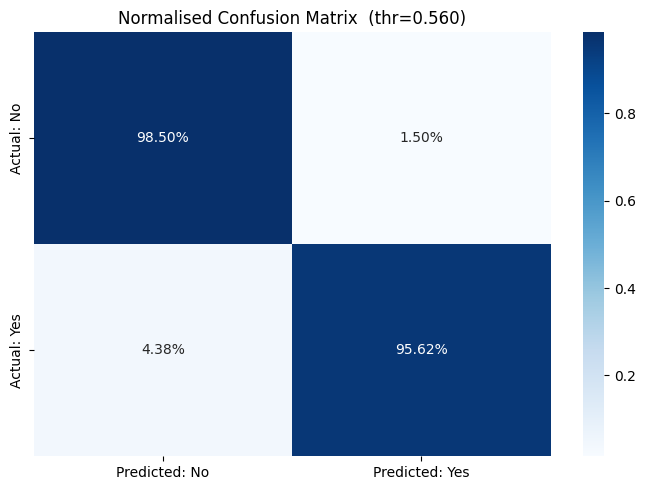

False Negatives (missed hyacinths): 7
False Positives (false alarms)    : 3


In [ ]:
y_true_test, y_prob_test = [], []
for images, labels in test_ds:
    y_prob_test.extend(model.predict(images, verbose=0).flatten())
    y_true_test.extend(labels.numpy().flatten())

y_true_test = np.array(y_true_test)
y_prob_test = np.array(y_prob_test)
y_pred_test = (y_prob_test > THRESHOLD).astype(int)

print("=" * 50)
print(f"Threshold used : {THRESHOLD:.4f}")
print(f"ROC-AUC        : {roc_auc_score(y_true_test, y_prob_test):.4f}")
print(f"PR-AUC         : {average_precision_score(y_true_test, y_prob_test):.4f}")
print(f"F1 (positive)  : {f1_score(y_true_test, y_pred_test):.4f}")
print("=" * 50)
print(classification_report(y_true_test, y_pred_test,
                             target_names=class_names))

# Normalised confusion matrix
cm = confusion_matrix(y_true_test, y_pred_test, normalize='true')
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No',  'Actual: Yes'])
plt.title(f'Normalised Confusion Matrix  (thr={THRESHOLD:.3f})')
plt.tight_layout()
plt.show()

# False-negative count (missed water hyacinths)
fn = np.sum((y_true_test == 1) & (y_pred_test == 0))
fp = np.sum((y_true_test == 0) & (y_pred_test == 1))
print(f"False Negatives (missed hyacinths): {fn}")
print(f"False Positives (false alarms)    : {fp}")


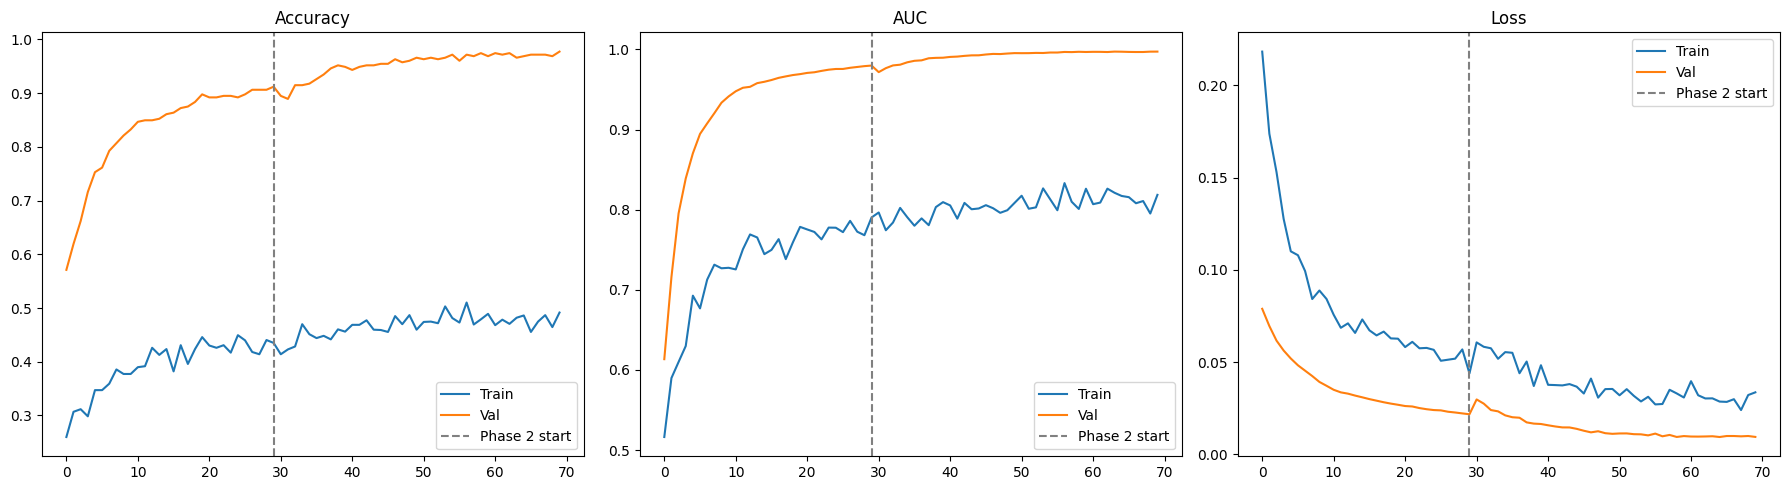

In [ ]:
def merge_histories(h1, h2, key):
    return h1.history[key] + h2.history[key]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epoch_range = range(len(merge_histories(history1, history2, 'accuracy')))

for ax, metric, title in zip(
        axes,
        ['accuracy', 'auc', 'loss'],
        ['Accuracy', 'AUC', 'Loss']):
    ax.plot(epoch_range, merge_histories(history1, history2, metric),       label='Train')
    ax.plot(epoch_range, merge_histories(history1, history2, f'val_{metric}'), label='Val')
    ax.axvline(len(history1.history['accuracy']) - 1,
               color='gray', linestyle='--', label='Phase 2 start')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()


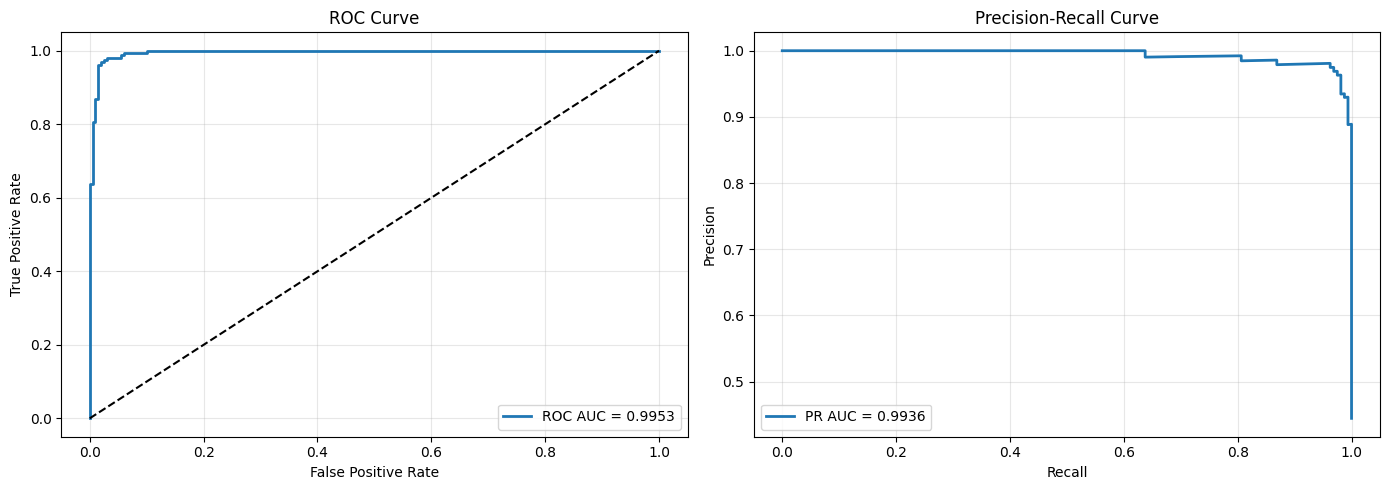

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr_t, tpr_t, _ = roc_curve(y_true_test, y_prob_test)
roc_auc_val      = auc(fpr_t, tpr_t)
ax1.plot(fpr_t, tpr_t, lw=2, label=f'ROC AUC = {roc_auc_val:.4f}')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()
ax1.grid(alpha=0.3)

# PR
prec_t, rec_t, _ = precision_recall_curve(y_true_test, y_prob_test)
pr_auc_val        = auc(rec_t, prec_t)
ax2.plot(rec_t, prec_t, lw=2, label=f'PR AUC = {pr_auc_val:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
test_file_ds = tf.keras.utils.image_dataset_from_directory(
    root_dir, validation_split=0.3, subset='validation',
    seed=SEED, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    label_mode='binary', shuffle=False)

all_files  = test_file_ds.file_paths
half       = len(all_files) // 2
test_files = all_files[half:]           # mirrors test_ds split

ds1_idx = [i for i, f in enumerate(test_files) if os.path.basename(f).startswith('d1')]
ds2_idx = [i for i, f in enumerate(test_files) if os.path.basename(f).startswith('d2')]

if len(ds1_idx) and len(ds2_idx):
    print("\n--- Domain Bias Analysis ---")
    for name, idx in [('DS1 (glendell03)', ds1_idx),
                      ('DS2 (Bangladesh)', ds2_idx)]:
        gt  = y_true_test[idx]
        pr  = y_pred_test[idx]
        if len(np.unique(gt)) > 1:
            print(f"\n{name}  (n={len(idx)})")
            print(classification_report(gt, pr, target_names=class_names,
                                        zero_division=0))
        else:
            print(f"\n{name}: only one class present — skipping report")
else:
    print("Not enough data per source to split; domain analysis skipped.")


Found 2374 files belonging to 2 classes.
Using 712 files for validation.
Not enough data per source to split; domain analysis skipped.
